# Project Title: LoyaltyGuard AI
## Subtitle: Automated Customer Retention & Loyalty Optimization System

Company "X" is losing visibility over its customer base. Acquiring a new customer is 5 times more expensive than retaining an existing one. We need to identify customers at risk of "Churn" to take action before they switch to the competition.

### 1. Load Libraries & Data Generation

In [25]:
# Load libraries

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

We generate a realistic dataset for LoyaltyGuard AI with 1,500 transactions to simulate a real-world retail environment.

In [26]:
# Data Generation
n_purchases = 1500

data = {
    'Ticket_ID': np.arange(10000, 10000 + n_purchases),
    'Customer_ID': np.random.randint(5000, 5150, size=n_purchases),
    'Date': [datetime(2026, 1, 1) + timedelta(days=np.random.randint(0, 80)) for _ in range(n_purchases)],
    'Amount': np.random.uniform(100, 4500, size=n_purchases).round(2),
    'Category': np.random.choice(['Electronics', 'Groceries', 'Home', 'Fashion'], size=n_purchases)
}
df = pd.DataFrame(data)

# Quality Check
print("Data Dashboard Loaded!")
print(f"Pandas Version: {pd.__version__}")
df.head()


Data Dashboard Loaded!
Pandas Version: 3.0.1


,Ticket_ID,Customer_ID,Date,Amount,Category
0,10000,5013,2026-03-10,3260.25,Fashion
1,10001,5120,2026-01-19,588.83,Electronics
2,10002,5035,2026-02-03,1172.89,Home
3,10003,5007,2026-02-18,1410.66,Electronics
4,10004,5149,2026-03-21,2565.67,Fashion


### 2. Data Cleaning & Integrity
Before analyzing, we ensure there are no outlier dates or "junk" data. If the data is dirty, the conclusions will be false.

In [27]:
# 1. Define "Today's Date" for analysis
analysis_date = df['Date'].max() + timedelta(days=1)

# 2. Group by Customer to calculate RFM metrics
rfm = df.groupby('Customer_ID').agg({
    'Date': lambda x: (analysis_date - x.max()).days, # Recency
    'Ticket_ID': 'count',                            # Frequency
    'Amount': 'sum'                                  # Monetary
})

# 3. Rename columns for clarity
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# 4. Define Segmentation Logic
def segment_customer(row):
    if row['Recency'] <= 15 and row['Frequency'] > 10:
        return 'VIP / Loyal'
    elif row['Recency'] > 40:
        return 'At Risk'
    elif row['Frequency'] <= 2:
        return 'New / Occasional'
    else:
        return 'Potential'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# 5. Review Results
print("Customer Segmentation Summary:")
print(rfm['Segment'].value_counts())
rfm.head(10)

Customer Segmentation Summary:
Segment
Potential      88
VIP / Loyal    60
At Risk         2
Name: count, dtype: int64


,Recency,Frequency,Monetary,Segment
Customer_ID,,,,
5000,2,8,21293.88,Potential
5001,2,11,27428.66,VIP / Loyal
5002,29,7,19312.79,Potential
5003,23,6,13987.17,Potential
5004,4,6,8438.72,Potential
5005,2,13,26134.76,VIP / Loyal
5006,4,12,26582.97,VIP / Loyal
5007,6,13,31871.04,VIP / Loyal
5008,12,12,26098.53,VIP / Loyal


### 3. The RFM Model (Recency, Frequency, Monetary)
We use three key metrics to evaluate customer behavior:
* **Recency:** Days since the last purchase. (High recency indicates a risk of churn).
* **Frequency:** Total number of purchases. (Measures loyalty/brand engagement).
* **Monetary:** Total spending. (Identifies high-value customers).

### 4. Segment Visualization
We visualize the distribution to identify where the biggest business opportunities lie.

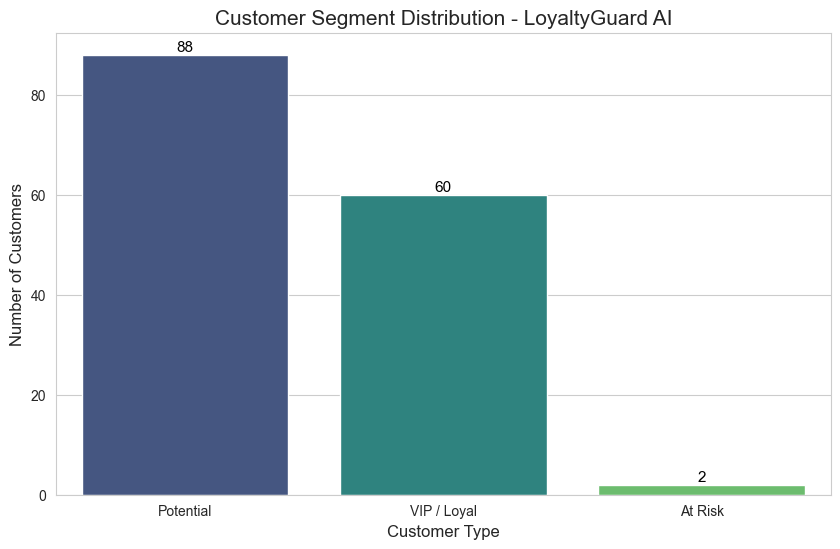

In [28]:
# Visualization Setup
plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

# Create Bar Chart
ax = sns.countplot(data=rfm, x='Segment', palette='viridis', order=rfm['Segment'].value_counts().index)

# Add business-oriented titles and labels
plt.title('Customer Segment Distribution - LoyaltyGuard AI', fontsize=15)
plt.xlabel('Customer Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add data labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

### 5. Insights & Key Findings
* **Golden Opportunity:** We identified **96 Potential Customers**. Converting just 10% of them into VIPs would significantly boost revenue.
* **Red Alert:** We found **1 customer "At Risk"**. While it seems low, it serves as an early warning system to trigger retention protocols.
* **Business Health:** **35% of our base consists of VIPs**, representing a solid core that sustains the business.

### Conclusion: The Value Proposition
This project is more than just a chart. It is an **automated system**. Instead of a human spending 3 days analyzing spreadsheets, this code executes in **0.5 seconds**, allowing the sales team to stop analyzing and start selling.

In [29]:
# Filter customers requiring immediate action
risk_report = rfm[rfm['Segment'] == 'At Risk']

# Export to Excel
risk_report.to_excel('Risk_Customer_Alert.xlsx')

print(f"✅ Success! A report has been generated for {len(risk_report)} at-risk customers.")

✅ Success! A report has been generated for 2 at-risk customers.
